# 🛳 Exploratory Data Analysis on Titanic Dataset

**Tools Used:** `pandas`, `numpy`, `matplotlib`, `seaborn`

**Covered Topics:**

 - Data Types & Missing Data

 - Data Cleaning

 - Summary Statistics & Group-based Insights

 - Data Visualization (bar plots, heatmaps, survival rates)

## 1. 📥 Import Libraries & Load Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set(style="whitegrid")

# Load dataset
df = sns.load_dataset('titanic')
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. 🔎 Basic Dataset Information

**Shape and Info**

In [3]:
print("Dataset shape:", df.shape)
df.info()


Dataset shape: (891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


**Check Missing Values**

In [4]:
df.isnull().sum()


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

**Quick Statistical Summary**

In [5]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. 🧹 Data Cleaning

### Handle Missing Values

 - Fill missing `Age` with median

 - Fill missing `Embarked` with mode

 - Drop `Cabin` (too many missing)

In [13]:
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [16]:
# data type conversion
 
df['survived'] = df['survived'].astype('category')
df['Pclass'] = df['pclass'].astype('category')
df['sex'] = df['sex'].astype('category')
df['embarked'] = df['embarked'].astype('category')

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    category
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    category
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    category
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
 15  Pclass       891 non-null    category
dtypes: bool(2), category(6), float64(2), int64(3), object(3)
memory usage: 63.8+ KB


## 4. 📊 Exploratory Analysis

**Survival Rate**

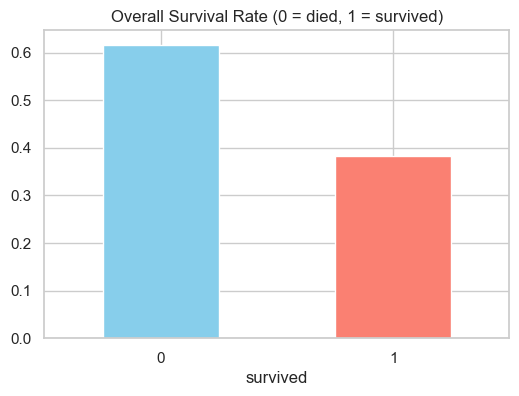

In [17]:
df['survived'].value_counts(normalize=True).plot(
    kind='bar',
    color=['skyblue','salmon'],
    figsize=(6,4),
    rot=0
)
plt.title("Overall Survival Rate (0 = died, 1 = survived)")
plt.show()


**Survival by Gender**

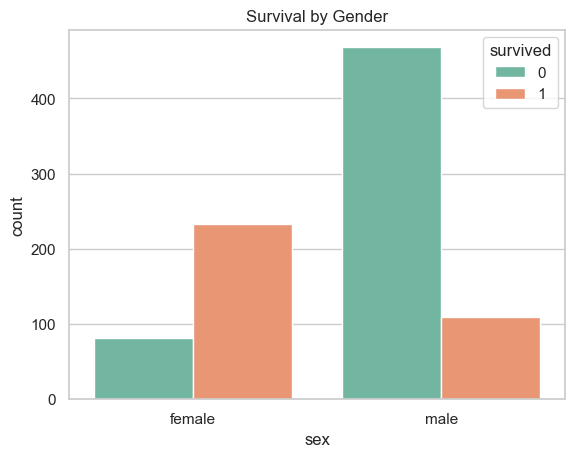

In [19]:
sns.countplot(x="sex", hue="survived", data=df, palette="Set2")
plt.title("Survival by Gender")
plt.show()


**Survival by Passenger Class**

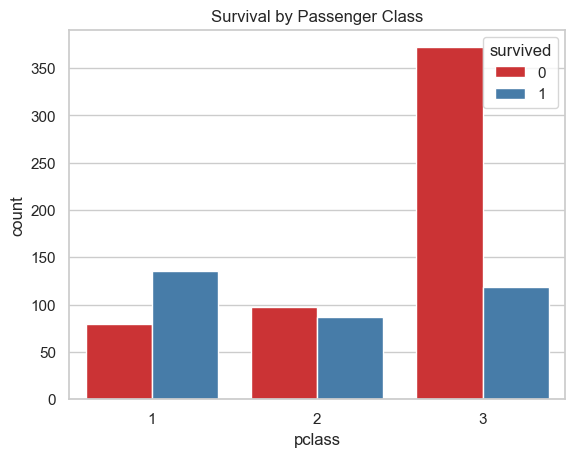

In [20]:
sns.countplot(x="pclass", hue="survived", data=df, palette="Set1")
plt.title("Survival by Passenger Class")
plt.show()


**Survival by Embarkation Port**

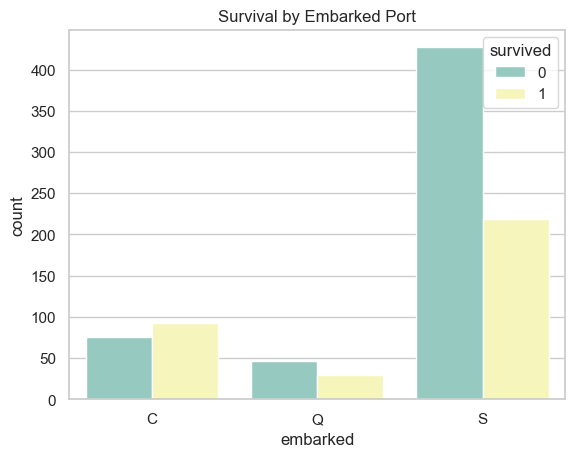

In [21]:
sns.countplot(x="embarked", hue="survived", data=df, palette="Set3")
plt.title("Survival by Embarked Port")
plt.show()


## 5. 📈 Correlation Analysis

**Correlation Heatmap**

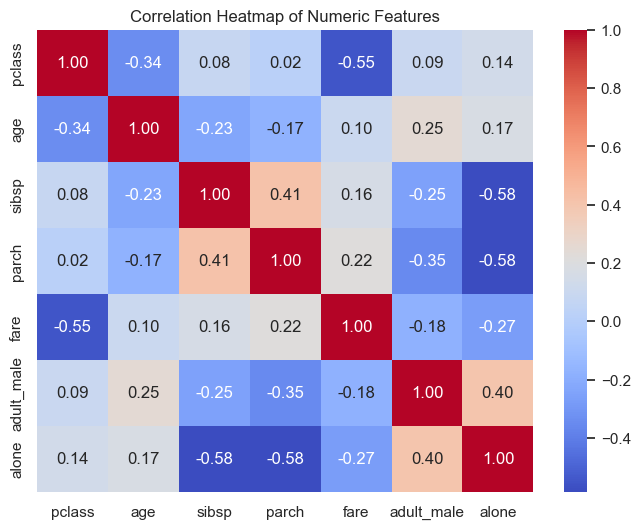

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


## 6. 🎯 Key Insights

 - Females had a much higher survival rate than males.

 - Higher-class passengers (`Pclass` = 1) had better survival chances.

 - Passengers embarking from `C` had slightly better chances than those from `S`.

 - Age had a weaker but noticeable correlation with survival (younger had better odds).

## ✅ Bonus:

**Survival rates using bar plots and heatmaps**

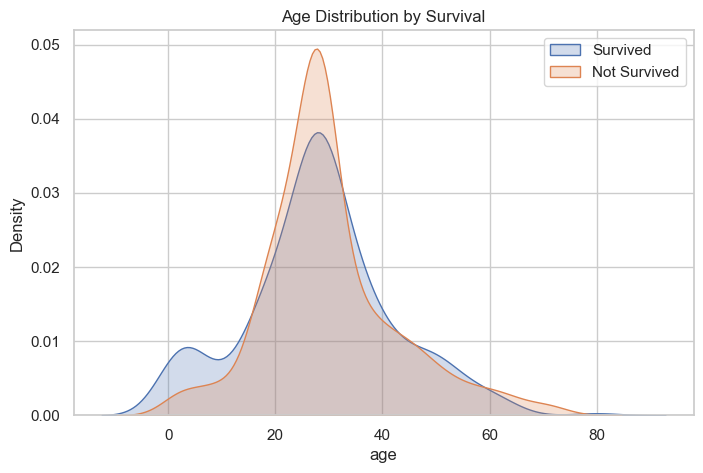

In [26]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df[df['survived']==1], x="age", fill=True, label="Survived")
sns.kdeplot(data=df[df['survived']==0], x="age", fill=True, label="Not Survived")
plt.title("Age Distribution by Survival")
plt.legend()
plt.show()

